# Homework 1

## Essential Information

* Deadline: Friday Feb 14th (11:59 PM)
* Independent Assignment: This assignment should be done independently
    * Sharing of solutions is not allowed
    * Discussing _approaches_ is discouraged. If this occurs please cite who you discussed with. I want you thinking through how to solve this problem on your own.
    * Collaborative support with the practicalities of coding (I.E. helping someone with pandas or the google colab environment) is encouraged and fine.

## Overview

This assignment is a series of exercises intended to explore basic recommendation techniques. Doing these exercises should:

* Prepare you to work with common tools, languages, and data formats for recsys work (circa 2025ish, the popular tools do change)
* Hone your basic data analysis skills before we do harder tasks with them.
* Give you richer experience with the _shape_ and _structure_ of recommender systems data.
* Give you practical experience with simple non-personalized and content-based approaches. While we might learn _better_ algorithms later in the semester, these simple approaches can often serve as a good way to "test the waters" to see what information seems most useful for making predictions in a domain.

As you work, make sure that you are not _speedrunning_ the assignment. I know it's easy to want to get the work done fast -- but an explicit part of this assignment is getting used to the nature of recommender system data at an intuitive level. This isn't something I can usefully teach you -- it's just something you need to see and experience for yourself. Make sure you're looking over data, trying out small tweaks and _exploring_ as you go.


## Outline

I've broken down this assignment into 5 core parts:

* (6 points) part 1 - basic data loading and exploration
* (24 points) part 2 - non-personalized algorithms and analysis
* (15 points) Part 3 - basic demographic analysis
* (15 points) part 4 - basic item association analysis
* (40 points) Part 5 - basic content-based algorithms

Most of these will call for you to implement a basic algorithm of computation, and then produce a practical result from it (often a top-10 movie list). Some questions will then ask you to follow-up with some practical evaluation in a series of short-answer questions.

## Notes:
 * All instructions are in-line in this document. We've tried to balance clarity with brevity here, which means that there might be a few instructions that we're _assuming_ are clear enough. If you're ever unclear what is expected or required of you please reach out over slack or email for clarification.
 * As _this_ document will be hard to meaningfully update after the assignment begins, make sure you regularly check canvas and slack for any updates, new hints or FAQs
 * While you are not required to use the pandas framework for doing this data analysis, it's commonly considered a power-tool for this sort of work, and you might find many parts of this assignment much easier _with_ pandas than without. I'm hoping to provide some pandas hints in lecture, and on slack, but I'm not an expert either. You are encouraged to read about pandas, and it's entirely reasonable to google around for how to perform some of these basic operations.

# How to get started and what to submit

To start this assignment, make a copy of this notebook: <https://colab.research.google.com/drive/1dVdMXltAZD3pGAgqlfV7li08L8zirS2e?usp=sharing>

by clicking File --> save a copy in Drive like below. Then please work on your copy.

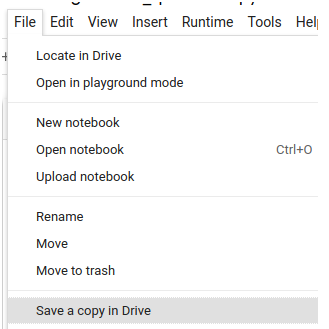

You will need to submit the EDITOR link of your notebook on Canvas (click share --> get link --> editor --> copy link).

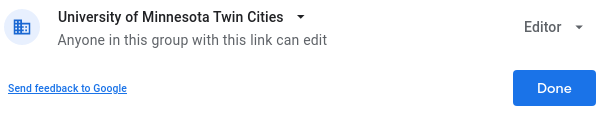


#Data loading and preperation

Note -- the first few code blocks here do a lot of required set-up. You shouldn't need to change this code, but you're free to do so if you feel like it. If those changes are important it might be worth adding a note here to draw our attention to it when reviewing your code.

In [1]:
# Get the MovieLens data
!wget -nc https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip -n 'ml-1m.zip'
!cat ml-1m/README

--2025-02-13 18:40:03--  https://files.grouplens.org/datasets/movielens/ml-1m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.65.152
Connecting to files.grouplens.org (files.grouplens.org)|128.101.65.152|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5917549 (5.6M) [application/zip]
Saving to: ‘ml-1m.zip’

ml-1m.zip           100%[===================>]   5.64M  17.1MB/s    in 0.3s    

2025-02-13 18:40:03 (17.1 MB/s) - ‘ml-1m.zip’ saved [5917549/5917549]

Archive:  ml-1m.zip
   creating: ml-1m/
  inflating: ml-1m/movies.dat        
  inflating: ml-1m/ratings.dat       
  inflating: ml-1m/README            
  inflating: ml-1m/users.dat         
SUMMARY

These files contain 1,000,209 anonymous ratings of approximately 3,900 movies 
made by 6,040 MovieLens users who joined MovieLens in 2000.

USAGE LICENSE

Neither the University of Minnesota nor any of the researchers
involved can guarantee the correctness of the data, its suitability
for any

In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# grab the item data and prepare it a little
items = pd.read_csv("ml-1m/movies.dat",
                    delimiter="::",
                    names=["movieId", "movieName", "genres"],
                    engine='python',
                    encoding="ISO-8859-1")

In [4]:
# genres from readme
genres = [
    "Action", "Adventure", "Animation", "Children's", "Comedy", "Crime",
    "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical",
    "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]
# temporary matrix with columns as genres and movies as rows
genre_matrix = pd.DataFrame(0, index=items.movieId, columns=genres)
# iterate over each movie and genre
# if the genre is in the movie's set of genres, put down a 1
count = 0
for idx, row in items.iterrows():
        count = idx
        movie_genres = row['genres'].split('|')
        for genre in movie_genres:
            if genre in genres:  # Check if genre is in our list
                genre_matrix.loc[row['movieId'], genre] = 1
# merge this into items.
items = items.merge(genre_matrix, on="movieId")
display(items)

,movieId,movieName,genres,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Animation|Children's|Comedy,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children's|Fantasy,0,1,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3878,3948,Meet the Parents (2000),Comedy,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3879,3949,Requiem for a Dream (2000),Drama,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3880,3950,Tigerland (2000),Drama,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3881,3951,Two Family House (2000),Drama,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
user = pd.read_csv("ml-1m/users.dat",
                    delimiter="::",
                    names=["userId", "gender", "age", "occupation_code", "zip_code"],
                    engine='python',
                    encoding="ISO-8859-1")
user

,userId,gender,age,occupation_code,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
...,...,...,...,...,...
6035,6036,F,25,15,32603
6036,6037,F,45,1,76006
6037,6038,F,56,1,14706
6038,6039,F,45,0,01060


In [6]:
ratings = pd.read_csv("ml-1m/ratings.dat",
                      delimiter="::",
                      names=["userId", "itemId", "rating", "tstamp"],
                      engine='python')
ratings

,userId,itemId,rating,tstamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [7]:
# Generate a rating_matrix
ratings_matrix = ratings.pivot(index='userId', columns='itemId', values='rating')
ratings_matrix

itemId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,NaN,NaN,NaN,2.0,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Part 1: Basic Data Exploration

Your task is to compute (or just find and record):

* How many users?
* How many items?
* How many ratings?

(Two histograms are also provided here as a helpful example)



In [8]:
# How many users?
nUsers = len(ratings['userId'].unique())
print(nUsers)

6040


In [9]:
# How many items?
nItems = len(ratings['itemId'].unique())
print(nItems)

3706


In [10]:
# How many ratings?
nRatings = ratings_matrix.count(axis=0).sum()
print(nRatings)

1000209


<Axes: ylabel='Frequency'>

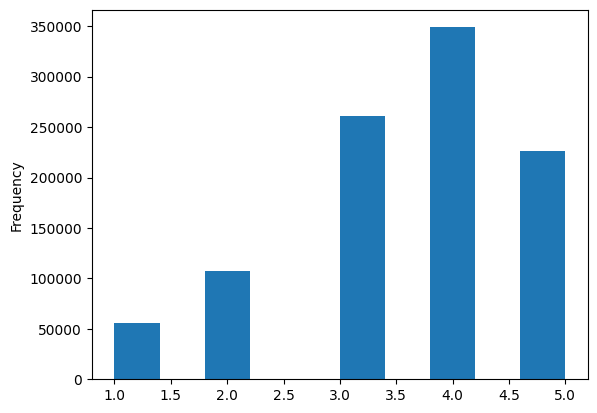

In [11]:
# Histogram of ratings (provided as a quick syntax example)
ratings['rating'].plot.hist()

20

2314

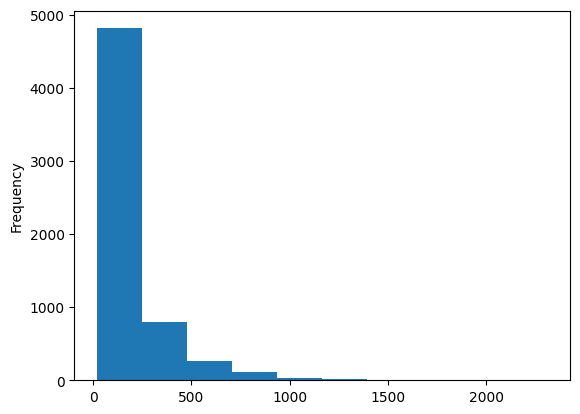

In [12]:
# the groupby function has lots of uses especially when doing a task like this one.
rating_count_by_user = ratings.groupby('userId')['rating'].count()
rating_count_by_user.rename('ratingCount', inplace=True)
# histogram the values.
# number of ratings vs number of users who rated that many
rating_count_by_user.plot.hist()
# also show the min and max.
display(min(rating_count_by_user),max(rating_count_by_user))

# Part 2: Non personalized Data Analysis

For this you'll be asked to compute some summary properties for each item, and then perform some light analysis

The algorithms you'll have to implement:


1.   average rating per movie
2.   damped average rating per movie (with damping factors 1, 10, 100, 1000)
3.   popularity (overall number of ratings) per movie
4.   percent of ratings 4 or higher (per movies)

For each of these 7 algorithms you should provide a top-10 list of movies. Please list these by movie Name (not by movieId.) and include their metric value.



In [13]:
# Top 10 movies by average ratings
item_average = ratings.groupby('itemId')['rating'].mean()
item_average.rename('item_avg', inplace=True)

item_names = items.set_index('movieId')['movieName'].to_frame()
items_and_average_named = item_names.merge(item_average.to_frame(), left_index=True, right_index=True)

items_and_average_named
top_ten_by_average = items_and_average_named.sort_values(by='item_avg', ascending=False).head(10)
top_ten_by_average


,movieName,item_avg
989,Schlafes Bruder (Brother of Sleep) (1995),5.0
3881,Bittersweet Motel (2000),5.0
1830,Follow the Bitch (1998),5.0
3382,Song of Freedom (1936),5.0
787,"Gate of Heavenly Peace, The (1995)",5.0
3280,"Baby, The (1973)",5.0
3607,One Little Indian (1973),5.0
3233,Smashing Time (1967),5.0
3172,Ulysses (Ulisse) (1954),5.0
3656,Lured (1947),5.0


In [14]:
# Prepare ratings variables for computation
item_count = ratings.groupby('itemId')['rating'].count()
item_sum = ratings.groupby('itemId')['rating'].sum()
global_average = ratings['rating'].mean()


In [15]:
# top 10 movies by damped average rating (damping factor 1)
damping_factor = 1

item_average_damped = (item_sum + (global_average * damping_factor)) / (item_count + damping_factor)
item_average_damped.rename('item_avg_damped_1', inplace=True)

items_and_average_damped_named = item_names.merge(item_average_damped.to_frame(), left_index=True, right_index=True)
top_ten_by_average_damped = items_and_average_damped_named.sort_values(by='item_avg_damped_1',ascending=False).head(10)
top_ten_by_average_damped

,movieName,item_avg_damped_1
787,"Gate of Heavenly Peace, The (1995)",4.645391
53,Lamerica (1994),4.620174
3245,I Am Cuba (Soy Cuba/Ya Kuba) (1964),4.596927
2905,Sanjuro (1962),4.594022
2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.558953
2503,"Apple, The (Sib) (1998)",4.558156
318,"Shawshank Redemption, The (1994)",4.554121
3233,Smashing Time (1967),4.527188
858,"Godfather, The (1972)",4.524542
745,"Close Shave, A (1995)",4.519121


In [16]:
# top 10 movies by damped average rating (damping factor 10)
damping_factor = 10

item_average_damped = (item_sum + (global_average * damping_factor)) / (item_count + damping_factor)
item_average_damped.rename('item_avg_damped_10', inplace=True)

items_and_average_damped_named = item_names.merge(item_average_damped.to_frame(), left_index=True, right_index=True)
top_ten_by_average_damped = items_and_average_damped_named.sort_values(by='item_avg_damped_10',ascending=False).head(10)
top_ten_by_average_damped

,movieName,item_avg_damped_10
318,"Shawshank Redemption, The (1994)",4.550208
2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.545166
858,"Godfather, The (1972)",4.520741
50,"Usual Suspects, The (1995)",4.511888
745,"Close Shave, A (1995)",4.506470
527,Schindler's List (1993),4.506403
1148,"Wrong Trousers, The (1993)",4.497551
2905,Sanjuro (1962),4.478679
1198,Raiders of the Lost Ark (1981),4.474174
922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.472533


In [17]:
# top 10 movies by damped average rating (damping factor 100)
damping_factor = 100

item_average_damped = (item_sum + (global_average * damping_factor)) / (item_count + damping_factor)
item_average_damped.rename('item_avg_damped_100', inplace=True)

items_and_average_damped_named = item_names.merge(item_average_damped.to_frame(), left_index=True, right_index=True)
top_ten_by_average_damped = items_and_average_damped_named.sort_values(by='item_avg_damped_100',ascending=False).head(10)
top_ten_by_average_damped

,movieName,item_avg_damped_100
318,"Shawshank Redemption, The (1994)",4.512744
858,"Godfather, The (1972)",4.484355
527,Schindler's List (1993),4.471779
50,"Usual Suspects, The (1995)",4.467422
1198,Raiders of the Lost Ark (1981),4.443442
2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.426039
260,Star Wars: Episode IV - A New Hope (1977),4.425479
1148,"Wrong Trousers, The (1993)",4.413601
904,Rear Window (1954),4.398397
745,"Close Shave, A (1995)",4.396508


In [18]:
# top 10 movies by damped average rating (damping factor 1000)
damping_factor = 1000

item_average_damped = (item_sum + (global_average * damping_factor)) / (item_count + damping_factor)
item_average_damped.rename('item_avg_damped_1000', inplace=True)

items_and_average_damped_named = item_names.merge(item_average_damped.to_frame(), left_index=True, right_index=True)
top_ten_by_average_damped = items_and_average_damped_named.sort_values(by='item_avg_damped_1000',ascending=False).head(10)
top_ten_by_average_damped

,movieName,item_avg_damped_1000
318,"Shawshank Redemption, The (1994)",4.253041
260,Star Wars: Episode IV - A New Hope (1977),4.235170
858,"Godfather, The (1972)",4.232257
527,Schindler's List (1993),4.229287
1198,Raiders of the Lost Ark (1981),4.222699
50,"Usual Suspects, The (1995)",4.180943
2762,"Sixth Sense, The (1999)",4.167842
2858,American Beauty (1999),4.151211
593,"Silence of the Lambs, The (1991)",4.136547
2028,Saving Private Ryan (1998),4.130458


In [19]:
# top 10 most popular movies
item_popularity = item_count.rename('popularity', inplace=False).to_frame()
items_and_popularity_named = item_names.merge(item_popularity, left_index=True, right_index=True)
top_ten_by_popularity = items_and_popularity_named.sort_values(by='popularity',ascending=False).head(10)
top_ten_by_popularity

,movieName,popularity
2858,American Beauty (1999),3428
260,Star Wars: Episode IV - A New Hope (1977),2991
1196,Star Wars: Episode V - The Empire Strikes Back...,2990
1210,Star Wars: Episode VI - Return of the Jedi (1983),2883
480,Jurassic Park (1993),2672
2028,Saving Private Ryan (1998),2653
589,Terminator 2: Judgment Day (1991),2649
2571,"Matrix, The (1999)",2590
1270,Back to the Future (1985),2583
593,"Silence of the Lambs, The (1991)",2578


In [20]:
# top 10 movies sorted by percent of ratings 4 or higher.
four_or_higher_count = (ratings[ratings['rating'] >= 4].groupby('itemId')['rating'].count())
four_or_higher_percent = (four_or_higher_count / item_count).rename('percent_4_or_higher', inplace=False).to_frame()
four_or_higher_percent_named = item_names.merge(four_or_higher_percent, left_index=True, right_index=True)
top_ten_by_higher_percent = four_or_higher_percent_named.sort_values(by='percent_4_or_higher',ascending=False).head(10)
top_ten_by_higher_percent

,movieName,percent_4_or_higher
878,Bye-Bye (1995),1.0
439,Dangerous Game (1993),1.0
1139,Everything Relative (1996),1.0
3647,Running Free (2000),1.0
3656,Lured (1947),1.0
3382,Song of Freedom (1936),1.0
717,Mouth to Mouth (Boca a boca) (1995),1.0
1795,"Callejón de los milagros, El (1995)",1.0
1830,Follow the Bitch (1998),1.0
1832,Heaven's Burning (1997),1.0


## 2.2 Additional reporting
Please provide a histogram of average rating per movie, and popularity per movie

1.0

5.0

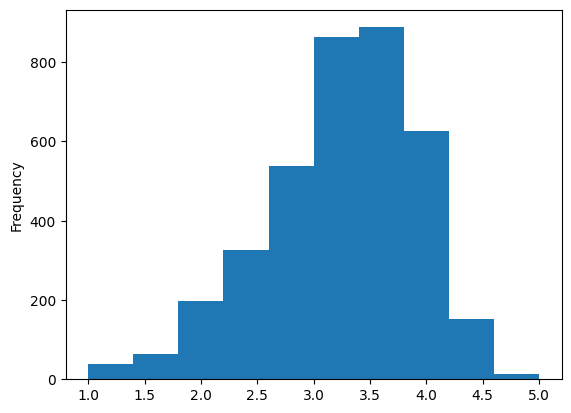

In [21]:
# histogram of average rating per movie:

# histogram the values.
# rating value vs number of movies with that average rating
item_average.plot.hist()
# also show the min and max.
display(min(item_average),max(item_average))

1

3428

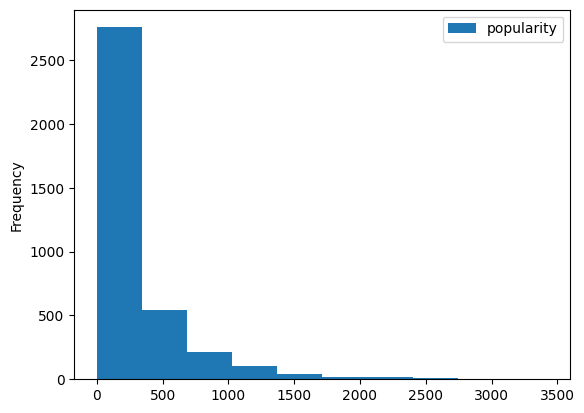

In [22]:
# histogram of movie popularity:
# histogram the values.
# rating value vs number of movies with that average rating
item_popularity.plot.hist()
# also show the min and max.
display(min(item_popularity['popularity']),max(item_popularity['popularity']))

## 2.3 Analysis

These analysis questions will be graded for factual correctness (so don't say something objectively not true) and for demonstrating thought about the data. These do not have a "correct answer" we're looking for, instead we want to see what you think after seeing the initial data. Each answer should be 1 or 2 sentences long, we don't need them to be longer.

Question 1: What damping factor would you recommend and why?

I think that a damping factor somewhere between 10 and 100 is the best range because it ensures that there are at least some movies presented to me that I haven't seen before. Higher damping factors result in lower novelty due to prioritizing popularity over raw mean.

Question 2: What is your opinion of the percent-greater-than-4 algorithm. Does it seem to work? if yes, why? If no, why not and what can be done about it?

This algorithm falls victim to the same issues as the raw mean algorithm and doesn't take into account the scarcity of reviews for some movies. The solution to this problem would be to introduce another damping factor, similar to how we did for the raw mean, to account for popularity.


# Part 3: Demographic approaches.

For this part you will repeat some of the tasks done above but making the computations separately for each gender (as self-reported in the user data)

You'll be asked to compute the damped average rating for each item (split by gender) and the item popularity (split by gender). You will report this both in the "top 10" form seen above, and in a "biggest gap" form (I.E the 5 movies where the male/female average rating is most higher than the opposite gender rating)

In [23]:
# Top 10 most popular movies among male identified users
male_users = user[user['gender'] == 'M']
male_ratings = ratings.merge(male_users, left_on='userId', right_on='userId')
male_ratings_popularity = male_ratings.groupby('itemId')['rating'].count()
male_ratings_popularity.rename('male_popularity', inplace=True)
male_ratings_popularity_named = item_names.merge(male_ratings_popularity.to_frame(), left_index=True, right_index=True)
top_ten_by_male_popularity = male_ratings_popularity_named.sort_values(by='male_popularity',ascending=False).head(10)
top_ten_by_male_popularity

,movieName,male_popularity
2858,American Beauty (1999),2482
260,Star Wars: Episode IV - A New Hope (1977),2344
1196,Star Wars: Episode V - The Empire Strikes Back...,2342
1210,Star Wars: Episode VI - Return of the Jedi (1983),2230
589,Terminator 2: Judgment Day (1991),2193
480,Jurassic Park (1993),2099
2028,Saving Private Ryan (1998),2078
2571,"Matrix, The (1999)",2076
1580,Men in Black (1997),2000
1270,Back to the Future (1985),1944


In [24]:
# Top 10 most popular movies among female identified users
female_users = user[user['gender'] == 'F']
female_ratings = ratings.merge(female_users, left_on='userId', right_on='userId')
female_ratings_popularity = female_ratings.groupby('itemId')['rating'].count()
female_ratings_popularity.rename('female_popularity', inplace=True)
female_ratings_popularity_named = item_names.merge(female_ratings_popularity.to_frame(), left_index=True, right_index=True)
top_ten_by_female_popularity = female_ratings_popularity_named.sort_values(by='female_popularity',ascending=False).head(10)
top_ten_by_female_popularity

,movieName,female_popularity
2858,American Beauty (1999),946
2396,Shakespeare in Love (1998),798
593,"Silence of the Lambs, The (1991)",706
2762,"Sixth Sense, The (1999)",664
1265,Groundhog Day (1993),658
608,Fargo (1996),657
1210,Star Wars: Episode VI - Return of the Jedi (1983),653
1196,Star Wars: Episode V - The Empire Strikes Back...,648
260,Star Wars: Episode IV - A New Hope (1977),647
356,Forrest Gump (1994),644


In [25]:
# Top 10 movies among male identified users (using damped-average-rating, damping factor 5)
damping_factor = 5

male_item_sum = male_ratings.groupby('itemId')['rating'].sum()
male_item_count = male_ratings.groupby('itemId')['rating'].count()
male_global_average = male_ratings['rating'].mean()

male_item_average_damped = (male_item_sum + (male_global_average * damping_factor)) / (male_item_count + damping_factor)
male_item_average_damped.rename('male_item_avg_damped', inplace=True)

male_item_average_damped_named = item_names.merge(male_item_average_damped.to_frame(), left_index=True, right_index=True)
male_top_ten_by_average_damped = male_item_average_damped_named.sort_values(by='male_item_avg_damped',ascending=False).head(10)
male_top_ten_by_average_damped

,movieName,male_item_avg_damped
858,"Godfather, The (1972)",4.580427
2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.567067
2905,Sanjuro (1962),4.558248
318,"Shawshank Redemption, The (1994)",4.557535
1198,Raiders of the Lost Ark (1981),4.518153
50,"Usual Suspects, The (1995)",4.514796
260,Star Wars: Episode IV - A New Hope (1977),4.493335
527,Schindler's List (1993),4.488692
1148,"Wrong Trousers, The (1993)",4.471255
904,Rear Window (1954),4.467074


In [26]:
# Top 10 movies among female identified users (using damped-average-rating, damping factor 5)
damping_factor = 5

female_item_sum = female_ratings.groupby('itemId')['rating'].sum()
female_item_count = female_ratings.groupby('itemId')['rating'].count()
female_global_average = female_ratings['rating'].mean()

female_item_average_damped = (female_item_sum + (female_global_average * damping_factor)) / (female_item_count + damping_factor)
female_item_average_damped.rename('female_item_avg_damped', inplace=True)

female_item_average_damped_named = item_names.merge(female_item_average_damped.to_frame(), left_index=True, right_index=True)
female_top_ten_by_average_damped = female_item_average_damped_named.sort_values(by='female_item_avg_damped',ascending=False).head(10)
female_top_ten_by_average_damped

,movieName,female_item_avg_damped
745,"Close Shave, A (1995)",4.616767
670,"World of Apu, The (Apur Sansar) (1959)",4.587576
1148,"Wrong Trousers, The (1993)",4.568320
527,Schindler's List (1993),4.555003
922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.533622
318,"Shawshank Redemption, The (1994)",4.531807
1207,To Kill a Mockingbird (1962),4.521645
720,Wallace & Gromit: The Best of Aardman Animatio...,4.519461
1223,"Grand Day Out, A (1992)",4.504393
50,"Usual Suspects, The (1995)",4.502636


In [27]:
# top 5 male-movies (I.E. movies where the average male rating is larger than the average female rating by the largest amount)
# Large positive values indicate male preference over female. Large negative values indicate female preference over male
damped_average_difference = male_item_average_damped - female_item_average_damped
damped_average_difference.rename('difference', inplace=True)
damped_average_difference_named = item_names.merge(damped_average_difference.to_frame(), left_index=True, right_index=True)
damped_average_difference_named.sort_values(by='difference',ascending=False).head(10)

,movieName,difference
1241,Braindead (1992),1.066126
1151,Faust (1994),1.063735
3338,For All Mankind (1989),0.895699
1255,Bad Taste (1987),0.861009
3737,Lonely Are the Brave (1962),0.842439
3415,"Mirror, The (Zerkalo) (1975)",0.816047
200,"Tie That Binds, The (1995)",0.810183
1859,Taste of Cherry (1997),0.727659
3659,Quatermass II (1957),0.718724
1201,"Good, The Bad and The Ugly, The (1966)",0.715840


In [28]:
# top 5 female-movies (I.E. movies where the average female rating is larger than the average make rating by the largest amount)
# Large positive values indicate male preference over female. Large negative values indicate female preference over male
damped_average_difference_named.sort_values(by='difference',ascending=True).head(10)

,movieName,difference
1335,Blood Beach (1981),-1.483196
2452,"Gate II: Trespassers, The (1990)",-1.270114
1313,Mad Dog Time (1996),-1.222203
626,"Thin Line Between Love and Hate, A (1996)",-1.212143
3574,Carnosaur 3: Primal Species (1996),-1.179470
1383,Adrenalin: Fear the Rush (1996),-1.160679
1168,Bad Moon (1996),-1.160408
3839,Phantasm IV: Oblivion (1998),-1.158223
2084,Newsies (1992),-1.092326
1720,Time Tracers (1995),-1.091724


## 3.2 Analysis
In your opinion, based on your results above, does demographic personalization based on self-reported gender seem to be a useful approach for recommending on MovieLens? Why, or why not?

I don't believe that gender has a lot to do with movie preference, and wouldn't say these results convince me otherwise. Especially in metrics such as popularity, it seems that there is very little meaningfully separating the demographics.

# Part 4 Basic Item Association Recommendation

In this section you'll implement some basic item association techniques to answer the following questions:

* What is the top movie for someone who has seen "Toy Story" (movie Id 1) by co-occurrence: Calculate movies that most often occur using the $\frac{|U_{i_1} \cap U_{i_2}|}{|U_{i_1}|}$ equation (I.E. the number of users watching both items, divided by the number of users who watched toy story overall). (show the top-10 movies)

* Calculate the Pearson correlation between the ratings of toy story and each other movie, then report the top-5 by high correlation. (Do not include toy story itself)

In [29]:
# For each movie -- compute it's co-occurance with toy story
target_movie_id = 1
top_k = 5

# describes, for each user userId, whether or not they rated item itemId
did_rate_matrix = ratings_matrix.notna()

# describes, for the target movie, whether or not each user rated it
did_rate_target = did_rate_matrix[target_movie_id]

# describes, for each movie itemId, the number of users who have also rated target_movie_id
did_rate_common_matrix = did_rate_matrix.apply(lambda column: column.mul(did_rate_target))
num_rate_target = did_rate_common_matrix.sum()
# display(num_rate_target)

# describes co-occurance, which describes a trend of how often all items occur with a relation to our target
co_occurance = num_rate_target / num_rate_target[target_movie_id]

# Show the top-5 movies by co-occurance
co_occurance.rename('co_occurance', inplace=True)
co_occurance = item_names.merge(co_occurance.to_frame(), left_index=True, right_index=True)
co_occurance.sort_values(by='co_occurance',ascending=False).head(top_k + 1)[1:]

,movieName,co_occurance
2858,American Beauty (1999),0.678382
1196,Star Wars: Episode V - The Empire Strikes Back...,0.670679
260,Star Wars: Episode IV - A New Hope (1977),0.665383
1265,Groundhog Day (1993),0.660087
1270,Back to the Future (1985),0.640828


In [30]:
# For each movie -- compute it's pearson correlation with toy story

# Generate a mean-corrected matrix for computation
mean_corrected_matrix = ratings_matrix.sub(item_average, axis=1).fillna(0)
mean_corrected_target = mean_corrected_matrix[target_movie_id]

# covariance / Pearson numerator
covariance = mean_corrected_matrix.T.dot(mean_corrected_target)

# standard deviation
matrix_sd = mean_corrected_matrix.apply(lambda x: x**2).sum()
target_sd = matrix_sd[target_movie_id]

# codeviation / Pearson denominator
codeviation = (matrix_sd * target_sd).apply(np.sqrt)

# correlation
correlation = covariance / codeviation

# Show the top-5 movies by correlation
correlation.rename('correlation', inplace=True)
correlation = item_names.merge(correlation.to_frame(), left_index=True, right_index=True)
correlation.sort_values(by='correlation',ascending=False).head(top_k + 1)[1:]

,movieName,correlation
3114,Toy Story 2 (1999),0.359299
588,Aladdin (1992),0.263130
2355,"Bug's Life, A (1998)",0.241819
595,Beauty and the Beast (1991),0.216925
364,"Lion King, The (1994)",0.204845


# Part 5 Content Filtering
For this part we'll implement a few basic content-based personalized recommenders. These will be based off the movie genres.

We will implement 3 basic approaches:

1. simple-count based
2. counts-with normalization
3. TF-IDF

All three will follow a few basic steps:
 * Summarize what movies the user likes into a user-genre vector
 * Summarize what genres a movie has
 * compute a dot-product to predict if the user will like a movie
 * Evaluate what percent of the observed ratings are predicted correctly.

## 5.1

In [31]:
# Data you will want:
display(items)
display(ratings_matrix)

,movieId,movieName,genres,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Animation|Children's|Comedy,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children's|Fantasy,0,1,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3878,3948,Meet the Parents (2000),Comedy,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3879,3949,Requiem for a Dream (2000),Drama,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3880,3950,Tigerland (2000),Drama,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3881,3951,Two Family House (2000),Drama,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


itemId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,NaN,NaN,NaN,2.0,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# Step 1: Data clean-up.
# Convert the provided rating_matrix so that all user-item pairs have a score between -1 and 1.
# Assign 1 if the user rated the item 4+,
# Assign -1 if the user rated the item 3 or less,
# Assign 0 if the user has not rated the item.
ratings_matrix_cleaned = ratings_matrix.apply(lambda x: x.apply(lambda y: 1 if y >= 4 else -1 if y <= 3 else 0))
ratings_matrix_cleaned

itemId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,-1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,0,0,0,-1,0,-1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6037,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6038,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
# Step 2: create a user-genre matrix.
# This matrix would be formed based off the user's sum of -1-to-1 ratings for all movies with that genre.
# For example, a user might like Star Wars Episode VI, Gladiator, Independence Day, The Matrix and dislike Star Wars Episode IV,
# That would give them an action-score of +3 (4 likes minus 1 dislike)
rated_movie_indices = ratings_matrix_cleaned.T.index
item_genre_matrix = items.set_index('movieId').loc[rated_movie_indices]
# clean item genre matrix for computation
item_genre_matrix = item_genre_matrix.drop(columns=['movieName','genres'])
user_genre_matrix = ratings_matrix_cleaned.dot(item_genre_matrix)

display(item_genre_matrix)
display(user_genre_matrix)

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
itemId,,,,,,,,,,,,,,,,,,
1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3948,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3949,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3950,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,
1,3,3,10,16,8,2,0,21,3,0,0,10,0,0,3,1,2,0
2,-4,3,0,0,3,0,0,25,-1,1,-2,0,-1,2,-1,-1,1,3
3,13,17,1,1,8,0,0,6,2,0,-1,1,-1,3,2,1,2,6
4,13,2,0,1,0,1,0,4,2,0,3,0,0,0,3,2,-1,2
5,-15,1,2,2,2,-1,2,-20,0,1,-6,1,-4,-12,-3,-13,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,-64,-41,10,-6,-71,3,7,52,-11,7,-24,7,2,-16,-95,-29,18,6
6037,4,7,1,0,5,2,1,32,2,-3,5,2,1,4,5,10,8,0
6038,0,1,1,-1,4,0,0,3,0,0,-2,0,0,4,1,0,2,0


In [34]:
# Step 3: Now that we have profiles for every user, and genre vectors for every item, let's see how good this model is.
# Create a user-by-item matrix and fill it in with the algorithms predictions for the user.
# The prediction is computed as the dot-product of the user's taste-vector with the item's genre vector.
user_item_genre_matrix = user_genre_matrix.dot(item_genre_matrix.T)

# After that -- compute how many observed ratings are predicted correctly (I.E have the same sign as the rating positive for "likes" and negative for "dislikes")
predictions = ratings_matrix_cleaned.mul(user_item_genre_matrix)

correct_predictions_cleaned = predictions.map(lambda x: 1 if x > 0 else np.nan)
incorrect_predictions_cleaned = predictions.map(lambda x: 1 if x < 0 else np.nan)

correct_predictions_by_item = correct_predictions_cleaned.sum().rename('correct_predictions')
correct_predictions_by_user = correct_predictions_cleaned.sum(axis=1).rename('correct_predictions')

incorrect_predictions_by_item = incorrect_predictions_cleaned.sum().rename('incorrect_predictions')
incorrect_predictions_by_user = incorrect_predictions_cleaned.sum(axis=1).rename('incorrect_predictions')

correct_num = correct_predictions_by_item.sum()
incorrect_num = incorrect_predictions_by_item.sum()
display("Total Incorrect: ", incorrect_num)
display("Total Correct: ", correct_num)

display(pd.concat([correct_predictions_by_user, incorrect_predictions_by_user], axis=1))
display(pd.concat([correct_predictions_by_item, incorrect_predictions_by_item], axis=1))

display("Total Accuracy: ", format(correct_num / (correct_num + incorrect_num), ".2%"))

'Total Incorrect: '

308771.0

'Total Correct: '

681679.0

,correct_predictions,incorrect_predictions
userId,,
1,45.0,7.0
2,81.0,47.0
3,37.0,14.0
4,18.0,3.0
5,124.0,74.0
...,...,...
6036,559.0,329.0
6037,120.0,81.0
6038,14.0,6.0


,correct_predictions,incorrect_predictions
itemId,,
1,1503.0,549.0
2,461.0,227.0
3,286.0,187.0
4,103.0,67.0
5,194.0,98.0
...,...,...
3948,533.0,314.0
3949,220.0,83.0
3950,37.0,17.0


'Total Accuracy: '

'68.83%'

## 5.2 Reweighting movies

You may have noticed that in our computation, a movie that had many genres checked could have more influence on the overall profile than one that had only a few. To explore this effect let's normalize each item's genre scores to form a unit length vector. We can do this in two steps:

1. Count the total number of genres in the row
2. Divide each value by the square root of that number of genres. If you do this right, items with two genres will have weighted scores 0.707; items with four genres will have scores of 0.5, etc. you can verify that if you take the length of these vectors(by summing the squares of each value), they sum to 1.


Once you have the new values, compute a second set of user profiles and a second count of how many of the observed ratings are accurate

In [35]:
item_genre_number = item_genre_matrix.sum(axis=1).rename('number_of_genres')
weighted_item_genre_matrix = item_genre_matrix.div(np.sqrt(item_genre_number), axis=0)

# The prediction is computed as the dot-product of the user's taste-vector with the item's genre vector.
user_item_genre_matrix = user_genre_matrix.dot(weighted_item_genre_matrix.T)

# After that -- compute how many observed ratings are predicted correctly (I.E have the same sign as the rating positive for "likes" and negative for "dislikes")
predictions = ratings_matrix_cleaned.mul(user_item_genre_matrix)

correct_predictions_cleaned = predictions.map(lambda x: 1 if x > 0 else np.nan)
incorrect_predictions_cleaned = predictions.map(lambda x: 1 if x < 0 else np.nan)

correct_predictions_by_item = correct_predictions_cleaned.sum().rename('correct_predictions')
correct_predictions_by_user = correct_predictions_cleaned.sum(axis=1).rename('correct_predictions')

incorrect_predictions_by_item = incorrect_predictions_cleaned.sum().rename('incorrect_predictions')
incorrect_predictions_by_user = incorrect_predictions_cleaned.sum(axis=1).rename('incorrect_predictions')

correct_num = correct_predictions_by_item.sum()
incorrect_num = incorrect_predictions_by_item.sum()
display("Total Incorrect: ", incorrect_num)
display("Total Correct: ", correct_num)

display(pd.concat([correct_predictions_by_user, incorrect_predictions_by_user], axis=1))
display(pd.concat([correct_predictions_by_item, incorrect_predictions_by_item], axis=1))

display("Total Accuracy: ", format(correct_num / (correct_num + incorrect_num), ".2%"))

'Total Incorrect: '

309395.0

'Total Correct: '

682321.0

,correct_predictions,incorrect_predictions
userId,,
1,45.0,7.0
2,81.0,47.0
3,37.0,14.0
4,18.0,3.0
5,124.0,74.0
...,...,...
6036,559.0,329.0
6037,120.0,81.0
6038,14.0,6.0


,correct_predictions,incorrect_predictions
itemId,,
1,1508.0,555.0
2,464.0,229.0
3,286.0,187.0
4,103.0,67.0
5,194.0,98.0
...,...,...
3948,533.0,314.0
3949,220.0,83.0
3950,37.0,17.0


'Total Accuracy: '

'68.80%'

## 5.3 Inverse Document Frequency

One way to take this a step further is to notice that some genres apply to almost every movie, and some apply quite rarely. This is often described as the document frequency of the genre. Adjusting for this may lead to better predictions.

1. First, create a vector of IDF terms. We'll use a common version, which is $\frac{1}{log10(frequency)}$ (where the frequency is how many times a genre has been used).
2. Next, when building your predictions, do a three-way multiplication (the vector representing the movie's genres, the vector representing the user's genre preferences, and the vector representing the IDF terms). (Use your vectors from part 5.2 after we applied normalization for user-preference and item-genre vectors)

Recompute these this way and again report the number of accurate predictions.

In [36]:
genre_idf = 1 / np.log(item_genre_matrix.sum())

# The prediction is computed as the dot-product of the user's taste-vector with the item's genre vector.
user_item_genre_matrix = user_genre_matrix.mul(genre_idf, axis=1).dot(weighted_item_genre_matrix.T)

# After that -- compute how many observed ratings are predicted correctly (I.E have the same sign as the rating positive for "likes" and negative for "dislikes")
predictions = ratings_matrix_cleaned.mul(user_item_genre_matrix)

correct_predictions_cleaned = predictions.map(lambda x: 1 if x > 0 else np.nan)
incorrect_predictions_cleaned = predictions.map(lambda x: 1 if x < 0 else np.nan)

correct_predictions_by_item = correct_predictions_cleaned.sum().rename('correct_predictions')
correct_predictions_by_user = correct_predictions_cleaned.sum(axis=1).rename('correct_predictions')

incorrect_predictions_by_item = incorrect_predictions_cleaned.sum().rename('incorrect_predictions')
incorrect_predictions_by_user = incorrect_predictions_cleaned.sum(axis=1).rename('incorrect_predictions')

correct_num = correct_predictions_by_item.sum()
incorrect_num = incorrect_predictions_by_item.sum()
display("Total Incorrect: ", incorrect_num)
display("Total Correct: ", correct_num)

display(pd.concat([correct_predictions_by_user, incorrect_predictions_by_user], axis=1),
        pd.concat([correct_predictions_by_item, incorrect_predictions_by_item], axis=1))

display("Total Accuracy: ", format(correct_num / (correct_num + incorrect_num), ".2%"))

'Total Incorrect: '

310046.0

'Total Correct: '

685136.0

,correct_predictions,incorrect_predictions
userId,,
1,45.0,7.0
2,82.0,47.0
3,37.0,14.0
4,18.0,3.0
5,124.0,74.0
...,...,...
6036,561.0,327.0
6037,120.0,81.0
6038,14.0,6.0


,correct_predictions,incorrect_predictions
itemId,,
1,1535.0,542.0
2,469.0,231.0
3,287.0,190.0
4,102.0,68.0
5,194.0,98.0
...,...,...
3948,533.0,314.0
3949,220.0,83.0
3950,37.0,17.0


'Total Accuracy: '

'68.85%'